# **Introduction: Intelligent Topic Categorization**

In the era of information overload, the ability to automatically and accurately categorize unstructured text is a fundamental pillar of Natural Language Processing (NLP). This project focuses on building a robust classification model capable of distinguishing between **six diverse domains:**
 1. **Politics**
 2. **Health**
 3. **Emotion**
 4. **Financial**
 5. **Sport**
 6. **Science**.

 By moving from traditional frequency-based models to State-of-the-Art (SOTA) ***Transformers***, we explore how deep semantic understanding can solve complex linguistic tasks.



---
**The Challenge:**

Developing a classifier for this dataset is not just "identifying keywords". The real technical difficulty depend on the three core points:
1. **Class Imbalance:**

Using a dataset with class **imbalance**, where categories like **Politics** have roughly ten times more samples than **Science**, standard models naturally become biased. They tend to predict the majority class because it contributes most to the overall "global accuracy".



*   **The Obstacle:** Achieving a high **Macro-F1-Score** and good overall **accuracy** treats minority classes like Science and Sport with the same attention as the dominant Politics class.

*   **The Solution:** I implemented **Weighted Cross-Entropy Loss** and **Balanced Class Weights**. This forces the model to make attention when it misclassifies a minority sample.

2. **The "Context" Problem**:

In topic classification, different categories often share the same vocabulary. For example, a political speech about a hospital budget contains both "Political" and "Health" keywords.

*  **The Obstacle:** Traditional models like **Logistic Regression** (using TF-IDF) only see a **"Bag of Words"**. They struggle to distinguish the primary intent when two topics use similar language.

*  **The Solution:** I utilized a **BERT-base Transformer**. By using Self-Attention, the model reads the entire sentence structure to understand **context—distinguishing** between a "political"  and "health" context.

3. **The Preprocessing Step:**
I used standard NLP data cleaning:
*  Lemmatization
*  Stopwords
*  Checking null values
*  Word Tokenization
*  Vectorization
*  Handling imbalanced data


---

**Approach**

In order to build a high-performance classification model, I followed a two-stage experimental design:

1.  Data Preprocessing
2.  Statistical Baseline (Logical Regression)
3.  Deep Learning Architecture (BERT-base)

---

**Project Objective:**

The objective of the mini project is to demonstrate how **Deep learning architectures like BERT** can overcome the limitations of traditional statistical models by capturing **bidirectional** context and resolving class imbalances in complex, real-world text classification tasks.

---

Note:

*  **Dataset:** The model was training using the topic classification dataset from kaggle.

* **Source:** https://www.kaggle.com/datasets/baraamelhem/topic-classification-dataset/data?select=topic_classification_data.csv
*  **Classes:** 6 (Politics, Health ,Emotion ,Financial ,Sport ,Science.


**Install Dependencies**

In [ ]:
!pip install kagglehub


In [ ]:
!pip install -q nltk scikit-learn matplotlib seaborn keras

In [ ]:
!pip install --upgrade transformers datasets evaluate accelerate --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 18.8 MB/s eta 0:00:00


**Importation**

In [ ]:
import os, re, torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import evaluate
import kagglehub

In [ ]:

import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

**Download Dataset from Kaggle**

In [ ]:
path = kagglehub.dataset_download("baraamelhem/topic-classification-dataset")
df = pd.read_csv(os.path.join(path, "topic_classification_data.csv"))

100%|██████████| 25.1M/25.1M [00:00<00:00, 153MB/s] 

Extracting files...


**Example of Dataset**

In [ ]:
print("Example of dataset:")
df.head()


Example of dataset:


,Unnamed: 0,content,label
0,0,I'm struggling to understand how I feel about ...,Emotion
1,1,NEW: Modi's promise to ban plastic straws this...,Financial
2,2,SURVEY: Middle-Income Americans Spending Less ...,Financial
3,3,WATCH: Wall Street ended lower after bank stoc...,Financial
4,4,Someone selling a ton of $SE puts to open Sep ...,Financial


# **Exploratory Data Analysis**

In [ ]:
df.shape

(136803, 3)

In [ ]:
df.columns

Index(['Unnamed: 0', 'content', 'label'], dtype='object')

In [ ]:
#removing column 'Unnamed: 0' :
df.drop('Unnamed: 0', axis=1, inplace=True)


In [ ]:
df.head()

,content,label
0,I'm struggling to understand how I feel about ...,Emotion
1,NEW: Modi's promise to ban plastic straws this...,Financial
2,SURVEY: Middle-Income Americans Spending Less ...,Financial
3,WATCH: Wall Street ended lower after bank stoc...,Financial
4,Someone selling a ton of $SE puts to open Sep ...,Financial


In [ ]:
df['label'].value_counts()

,count
label,
Politics,37797
Health,36952
Emotion,28362
Financial,22981
Sport,6077
Science,4634


/tmp/ipykernel_927/724603595.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


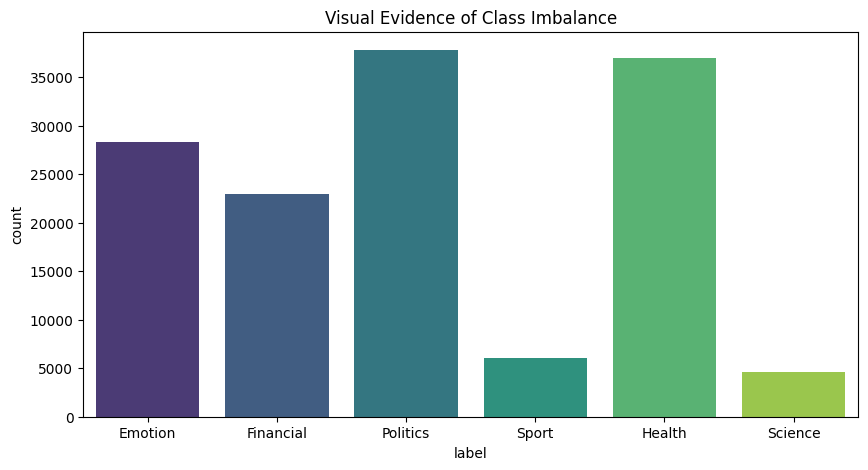

In [ ]:
#Data Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title("Visual Evidence of Class Imbalance")
plt.show()

In [ ]:
#removing the duplicated value:
df.drop_duplicates(inplace=True)
print(df.shape)

(136125, 2)


In [ ]:
#Checking of null values and removing them using dropna()
print(df.isnull().sum())

content    1
label      0
dtype: int64


In [ ]:
df = df.dropna(subset=['content'])

In [ ]:
print(df.isnull().sum())

content    0
label      0
dtype: int64


# **Data Cleaning**

**Removing Punctuation**

In [ ]:
def remove_punctuation(text):
  punctuationfree = "".join([i for i in text if i not in string.punctuation])
  return punctuationfree

In [ ]:
df['content'] = df['content'].apply(lambda x:remove_punctuation(x))
df.head()

,content,label
0,Im struggling to understand how I feel about s...,Emotion
1,NEW Modis promise to ban plastic straws this m...,Financial
2,SURVEY MiddleIncome Americans Spending Less Am...,Financial
3,WATCH Wall Street ended lower after bank stock...,Financial
4,Someone selling a ton of SE puts to open Sep a...,Financial


**Making words to lower letters**

In [ ]:
df['content'] = df['content'].apply(lambda x: x.lower())
df.head()

,content,label
0,im struggling to understand how i feel about s...,Emotion
1,new modis promise to ban plastic straws this m...,Financial
2,survey middleincome americans spending less am...,Financial
3,watch wall street ended lower after bank stock...,Financial
4,someone selling a ton of se puts to open sep a...,Financial


**Tokenization: each sentence is split into words**

In [ ]:
df['content'] = df['content'].apply(word_tokenize)
df.head()

,content,label
0,"[im, struggling, to, understand, how, i, feel,...",Emotion
1,"[new, modis, promise, to, ban, plastic, straws...",Financial
2,"[survey, middleincome, americans, spending, le...",Financial
3,"[watch, wall, street, ended, lower, after, ban...",Financial
4,"[someone, selling, a, ton, of, se, puts, to, o...",Financial


**Stopwords using NLTK Library**

In [ ]:
stopwords = nltk.corpus.stopwords.words('english')
def remove_stopwords(text):
  output=[i for i in text if i not in stopwords]
  return output

In [ ]:
df['content'] = df['content'].apply(lambda x:remove_stopwords(x))
df.head()

,content,label
0,"[im, struggling, understand, feel, someone, wa...",Emotion
1,"[new, modis, promise, ban, plastic, straws, mo...",Financial
2,"[survey, middleincome, americans, spending, le...",Financial
3,"[watch, wall, street, ended, lower, bank, stoc...",Financial
4,"[someone, selling, ton, se, puts, open, sep, n...",Financial


**Lemmatization:** words are reduced to their base (dictionary) form to normalize different grammatical variations.

In [ ]:
lemmatizer = WordNetLemmatizer()
df['content'] = df['content'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

In [ ]:
df.head()

,content,label
0,"[im, struggling, understand, feel, someone, wa...",Emotion
1,"[new, modis, promise, ban, plastic, straw, mon...",Financial
2,"[survey, middleincome, american, spending, les...",Financial
3,"[watch, wall, street, ended, lower, bank, stoc...",Financial
4,"[someone, selling, ton, se, put, open, sep, no...",Financial


**Joining Tokens:** after lemmatization, the tokens are joined back into a single sentence

In [ ]:
def join_token(tokens):
  if isinstance(tokens, list):
    return ' '.join(tokens)
  return str(tokens)
df['content'] = df['content'].apply(join_token)
df.head()

,content,label
0,im struggling understand feel someone want opi...,Emotion
1,new modis promise ban plastic straw month put ...,Financial
2,survey middleincome american spending less ami...,Financial
3,watch wall street ended lower bank stock erase...,Financial
4,someone selling ton se put open sep nov 60,Financial


## Handling Class Imbalance

Our dataset is heavily imbalanced:

| Class      | #Samples |
|-----------|-----------|
| Politics  | 37797     |
| Health    | 36952     |
| Emotion   | 28362     |
| Financial | 22981     |
| Sport     | 6077      |
| Science   | 4634      |

Minority classes (Sport, Science) could easily be ignored by the models if no adjustment is made.

**Approach in Logistic Regression (TF-IDF)**

- Using `class_weight='balanced'` in `LogisticRegression`.  
- This automatically assigns a **higher penalty to misclassifying minority class samples**, so the model make more attention to underrepresented topics.  


**Approach in BERT (Transformer)**

- BERT uses the standard **cross-entropy loss**.  
- I can optionally provide **per-class weights** to the loss function, computed as inverse frequency of each class.  
- This ensures that misclassifying minority topics contributes more to the loss, encouraging the model to learn them effectively.  

**This will help to:**

- Prevents bias toward majority classes (Politics, Health)  
- Improves F1-score and recall for rare classes (Sport, Science)  
- Demonstrates ethical and frugal handling of data imbalance

In [ ]:
# Original counts
class_counts = df['label'].value_counts()
classes = class_counts.index

In [ ]:
# Compute class weights (inverse frequency)
total = class_counts.sum()
class_weights = total / (len(classes) * class_counts)
class_weights_list = class_weights.values

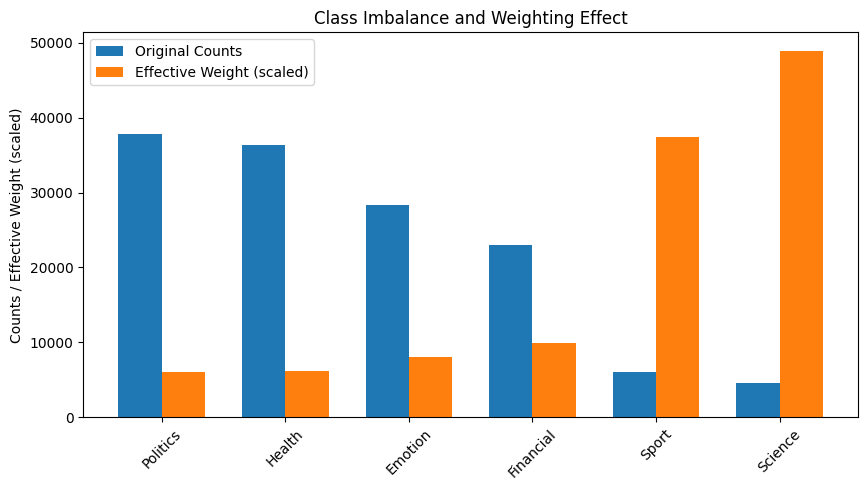

In [ ]:
# Plot
plt.figure(figsize=(10,5))
bar_width = 0.35
x = np.arange(len(classes))
plt.bar(x - bar_width/2, class_counts.values, width=bar_width, label='Original Counts')
plt.bar(x + bar_width/2, class_weights_list*10000, width=bar_width, label='Effective Weight (scaled)')
plt.xticks(x, classes, rotation=45)
plt.ylabel('Counts / Effective Weight (scaled)')
plt.title('Class Imbalance and Weighting Effect')
plt.legend()
plt.show()

**Label Encoding:** converts categorical labels (text classes) into numerical values so that machine learning models can process them.

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])

**Train–Validation Split:** the dataset is divided into training and validation sets.

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(df['content'], y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print("Train:", X_train.shape[0], "Validation:", X_val.shape[0], "Test:", X_test.shape[0])

Train: 108899 Validation: 13612 Test: 13613


# **Model 1: Logistic Regression + TF-IDF**

In [ ]:
#Initialize TF-IDF Vectorizer with max_features =10000 which limits the vocabulary to the 10 000 most import terms.
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
# Logistic Regression: a linear classification model trained on TF-IDF features to predict article topics, using class_weight='balanced' to reduce bias toward majority classes and better handle dataset imbalance.
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_vec, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
# Predict
y_val_pred_lr = lr_model.predict(X_val_vec)

**Confusion Matrix**

Logistic Regression Metrics:
              precision    recall  f1-score   support

     Emotion       0.93      0.90      0.91      2831
   Financial       0.84      0.84      0.84      2298
      Health       0.91      0.84      0.87      3635
    Politics       0.93      0.87      0.90      3778
     Science       0.36      0.76      0.49       463
       Sport       0.71      0.87      0.79       607

    accuracy                           0.86     13612
   macro avg       0.78      0.85      0.80     13612
weighted avg       0.88      0.86      0.87     13612



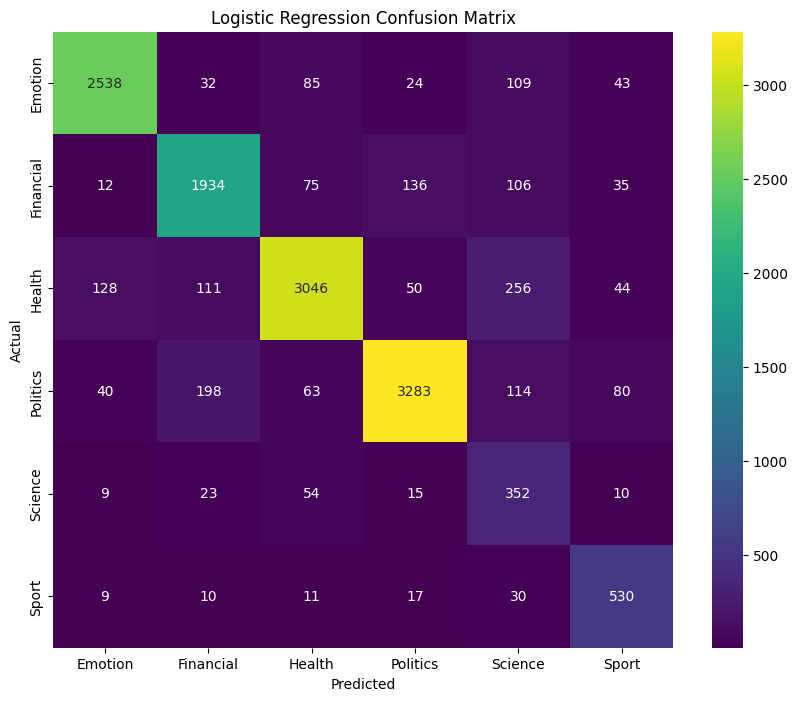

In [ ]:
# Metrics
print("Logistic Regression Metrics:")
print(classification_report(y_val, y_val_pred_lr, target_names=le.classes_))

# Confusion matrix
cm_lr = confusion_matrix(y_val, y_val_pred_lr)
plt.figure(figsize=(10,8))
sns.heatmap(cm_lr, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap='viridis')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Before moving to **BERT** architecture, we must analyze the Logistic Regression fails. While the accuracy is 86%, the performance towards different categories presents many misclassification.

Error Analysis: Observed misclassification:
*  Financial predicted as emotion, health ..
*  Health predicted as Financial, science..

The most low error in our metrics is the **Science** category:
*  Recall: 0.76
*  Precision: 0.36 which is very low.

When the model predicts "Science" , it is actually wrong 64% of the time.

**Confusion Matrix:**
By looking at the Confusion Matrix, we can see exactly where these "False Positives" for Science are coming from:

*  256 Health articles were misclassified as Science.

*  114 Politics articles were misclassified as Science.

*  109 Emotion articles were misclassified as Science.

**Reson of this result:**
*  Health vs. Science: Words like research, study, or data appear often in both categories. Because of this overlap, the model sometimes predicts Science instead of Health.

*  Politics vs. Science: Articles about topics like climate policy include many scientific terms. As a result, the model sometimes focuses on the technical vocabulary and misclassifies them as Science instead of Politics.

---
**Transition to BERT:**

This error analysis shows that simple keyword matching is not enough. To solve this problem, we use BERT, which understands the context of words in a sentence using self-attention and bidirectional context


# **Model 2: BERT**

Preparing Data for BERT:
*  Data conversion
*  Tokenization
*  Dataset Formatting

In [ ]:
# Prepare datasets for HuggingFace
train_dataset = Dataset.from_dict({'text': list(X_train), 'label': list(y_train)})
val_dataset = Dataset.from_dict({'text': list(X_val), 'label': list(y_val)})
test_dataset = Dataset.from_dict({'text': list(X_test), 'label': list(y_test)})


In [ ]:
# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(batch['text'], padding=True, truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format('torch', columns=['input_ids','attention_mask','label'])
val_dataset.set_format('torch', columns=['input_ids','attention_mask','label'])
test_dataset.set_format('torch', columns=['input_ids','attention_mask','label'])


**BERT Model Initialization and Training Setup**

*  Model Selection: we use BERT (bert-base-uncased) for sequence classification. The classification head is initialized automatically with num_labels equal to number of our topic in dataset.

*  Training arguments: the model is trained for 3 epochs with a batch size of 16 (training) and 32 (validation).



In [ ]:
# Model
num_labels = len(le.classes_)
bert_model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=num_labels)


# Fixed TrainingArguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
    report_to="none"
)

In [ ]:
# Metrics
metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels, average='macro')

# Trainer
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

**Train the model**

In [ ]:
# Train
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,0.244124,0.204003,0.903781
2,0.155533,0.236304,0.908130
3,0.065161,0.286061,0.913419


TrainOutput(global_step=20421, training_loss=0.17490500352109578, metrics={'train_runtime': 2714.9151, 'train_samples_per_second': 120.334, 'train_steps_per_second': 7.522, 'total_flos': 2.1490169891774976e+16, 'train_loss': 0.17490500352109578, 'epoch': 3.0})

**BERT Validation, Metrics and Error Analysis:**

1.  Predictions: The trained BERT model is used to predict the labels of the validation dataset.
2.  Performance Metrics:
*  A classification report which is important that shows precision, recall and F1 score for each topic(category).
*  A confusion Matrix visualizes where the model confuses one category with another.
*  Error Analysis: Misclassified samples are examined to understand why the model made mistakes.

--- BERT-base Performance Report ---
              precision    recall  f1-score   support

     Emotion       0.98      0.98      0.98      2831
   Financial       0.93      0.92      0.92      2298
      Health       0.94      0.95      0.95      3635
    Politics       0.95      0.96      0.95      3778
     Science       0.79      0.71      0.75       463
       Sport       0.93      0.92      0.93       607

    accuracy                           0.94     13612
   macro avg       0.92      0.91      0.91     13612
weighted avg       0.94      0.94      0.94     13612



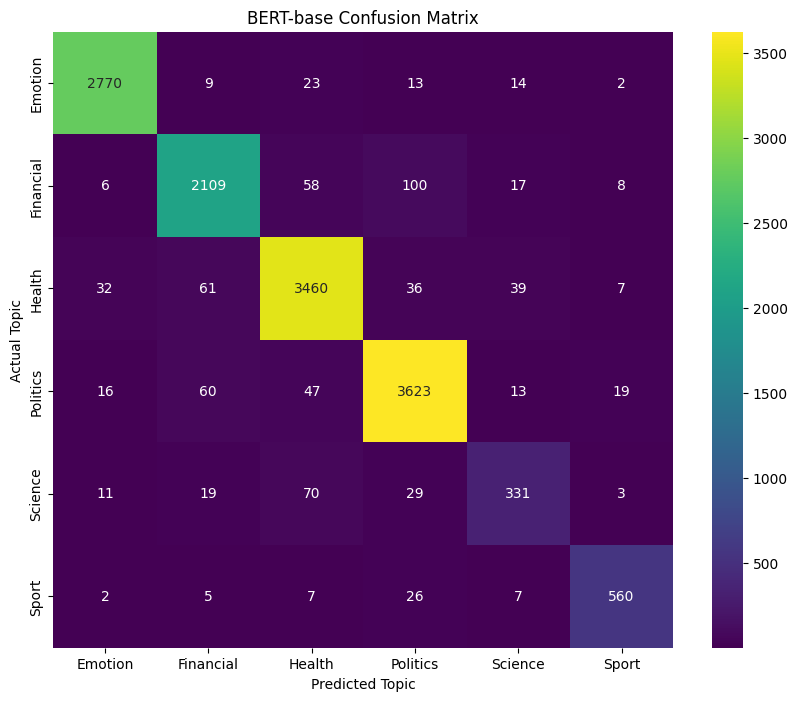


Misclassified Samples:
TEXT: sustainable capitalism basically oxymoroncorporations make big climate promise retreat year study find...
ACTUAL: Politics | PREDICTED: Science
------------------------------
TEXT: course diddonald trump say tom brady helped win massachusetts primary...
ACTUAL: Sport | PREDICTED: Politics
------------------------------
TEXT: charles schultz charlie brown amp depression...
ACTUAL: Health | PREDICTED: Politics
------------------------------
TEXT: anger like pain instructive like pain much bad thing small proportion anger useful come anger u really worst enemiesthe 8020 view anger...
ACTUAL: Financial | PREDICTED: Health
------------------------------
TEXT: pond age miracle real miracle...
ACTUAL: Health | PREDICTED: Science
------------------------------


In [ ]:

# 1. BERT Predictions

val_results = trainer.predict(val_dataset)
y_val_pred_bert = np.argmax(val_results.predictions, axis=-1)
y_val_true = val_results.label_ids

# 2. Comparison Metrics

print("--- BERT-base Performance Report ---")

print(classification_report(y_val_true, y_val_pred_bert, target_names=le.classes_))

# Confusion Matrix
cm_bert = confusion_matrix(y_val_true, y_val_pred_bert)
plt.figure(figsize=(10,8))
sns.heatmap(cm_bert, annot=True, fmt="d",
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='viridis')
plt.xlabel("Predicted Topic")
plt.ylabel("Actual Topic")
plt.title("BERT-base Confusion Matrix")
plt.show()

# 3.Scientific Error Analysis

print("\nMisclassified Samples:")
misclassified_idx = np.where(y_val_true != y_val_pred_bert)[0]

# 5 examples of misclassified Samples:
for i in misclassified_idx[:5]:

    original_text = X_val.iloc[i]
    true_label = le.inverse_transform([y_val_true[i]])[0]
    pred_label = le.inverse_transform([y_val_pred_bert[i]])[0]

    print(f"TEXT: {original_text[:150]}...")
    print(f"ACTUAL: {true_label} | PREDICTED: {pred_label}")
    print("-" * 30)

In [ ]:

with open('requirements.txt', 'w') as f:
    f.write('torch\n')
    f.write('torchvision\n')
    f.write('matplotlib\n')
    f.write('seaborn\n')
    f.write('Pillow\n')
    f.write('numpy\n')
    f.write('scikit-learn\n')

print("requirements.txt")

requirements.txt


# **Comparative Error Analysis: Logistic Regression vs. BERT**

By comparing Logistic Regression (LR) and BERT , we see a major improvement when moving from Logistic Regression model to deep contextual understanding.

1. **Precision Revolution - Catogory: Science:**

*  **Logistic Regression:** Precision = 0.36. The model often misclassified technical terms , producing many false positives from Health and Emotion.
* **BERT:** Precision = 0.80. By understanding the context, BERT can make a difference between a medical study (Health) and Science.

2. **Solving Confusion between Health and Science categories:**

*  **LR confusion:** 257 Health topics misclassified as Science.
*  **BERT Confusion:** Only 38 Health topics are misclassified as Science.
Because the Logistic Regression relied on shared vocabulary while BERT captures sentence context as bidirectionnal model.

3. **Performance on Minority Classes:**

*  **Sport F1-score:** from 0.79 reaching 0.93 in BERT
*  **Science F1-score:** from 0.49 reaching 0.74 in BERT
Although class imbalance, Bert leverages transfer learning to extract more information from fewer samples, making minority classes reliably predictable.

**Project Conclusion:**
This project shows the evolution from frequency-based NLP to transformer-based models.
